In [1]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

# Dask will automatically submit SLURM jobs for you
cluster = SLURMCluster(
    cores=8,
    memory="128GB",
    processes=8,
    walltime="08:00:00",
    #qos="np",
    #account='spitfabi',
    #interface='ib0'  # or 'eth0', depends on your HPC
    job_extra_directives=[
        "--account=spitvent",
        "--qos=np"
        # "--constraint=haswell",
        # "--exclusive",
        # "--mail-type=END,FAIL",
        # "--mail-user=your.email@domain.com"
    ]
)

# Scale to desired number of workers
cluster.scale(jobs=1)  # This submits 1 SLURM job
# Connect client
client = Client(cluster)
#cluster.adapt(minimum_jobs=1, maximum_jobs=4)


/perm/itcv/Miniforge3/envs/clima/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37699 instead
  warnings.warn(


In [2]:
import check_run as cr
from matplotlib import pyplot as plt
import xarray as xr
import os
from scipy import stats
import numpy as np
import cartopy.crs as ccrs

In [7]:
import importlib as imp
imp.reload(cr)

<module 'check_run' from '/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py'>

In [4]:
read_again = []

cart_exp = '/ec/res4/scratch/{}/ece4/'
cart_out = '/ec/res4/hpcperm/itcv/analysis/'


In [5]:
exps = [ ['pct6', 'pic6'], ['pct7', 'pic7'],['pct1', 'pic1'], ['pct3', 'pic3'], ['pct2', 'pic2'], ['pct4', 'pic4'], ['1pc0', 'ctl0']]
colors=['violet', 'purple', 'orange', 'indianred','steelblue','forestgreen', 'maroon']

In [7]:
# imp.reload(cr)
# fig, axs = plt.subplots(7,3, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(15,20))
# #fig2, bxs = plt.subplots(7,1, figsize = (8,22))

# map_70 = np.zeros([7,90,180])
# for i, exp in enumerate(exps):
#     map_70, lats, lons = cr.plot_anom_map(exp, 'itcv', var='psi', map70=map_70,index=i, domain='atm3d', vlevel=500, label = 'C', ref_exp=exp[1], cart_exp=cart_exp, cart_out=cart_out, ax=axs[i])

In [11]:
for i, exp in enumerate(exps):
    ds_out = cr.extract_variables_at_level(input_file  = cart_out+'exps_clim/'+f'map_atm3d_tuning_{exp[0]}_analysis.nc',
    output_file = cart_out+'exps_clim/'+f'map_atm3d_tuning_{exp[0]}_500hPa.nc',
    variables   = ['omega'],
    level       = 50000,
    level_dim   = 'pressure_levels',
    level_units = 'Pa'
)
    ds_out = cr.extract_variables_at_level(input_file  = cart_out+'exps_clim/'+f'map_atm3d_tuning_{exp[1]}_analysis.nc',
    output_file = cart_out+'exps_clim/'+f'map_atm3d_tuning_{exp[1]}_500hPa.nc',
    variables   = ['omega'],
    level       = 50000,
    level_dim   = 'pressure_levels',
    level_units = 'Pa'
)


Saved ['omega'] at 50000 Pa → /ec/res4/hpcperm/itcv/analysis/exps_clim/map_atm3d_tuning_pct6_500hPa.nc
Saved ['omega'] at 50000 Pa → /ec/res4/hpcperm/itcv/analysis/exps_clim/map_atm3d_tuning_pic6_500hPa.nc
Saved ['omega'] at 50000 Pa → /ec/res4/hpcperm/itcv/analysis/exps_clim/map_atm3d_tuning_pct7_500hPa.nc
Saved ['omega'] at 50000 Pa → /ec/res4/hpcperm/itcv/analysis/exps_clim/map_atm3d_tuning_pic7_500hPa.nc
Saved ['omega'] at 50000 Pa → /ec/res4/hpcperm/itcv/analysis/exps_clim/map_atm3d_tuning_pct1_500hPa.nc
Saved ['omega'] at 50000 Pa → /ec/res4/hpcperm/itcv/analysis/exps_clim/map_atm3d_tuning_pic1_500hPa.nc
Saved ['omega'] at 50000 Pa → /ec/res4/hpcperm/itcv/analysis/exps_clim/map_atm3d_tuning_pct3_500hPa.nc
Saved ['omega'] at 50000 Pa → /ec/res4/hpcperm/itcv/analysis/exps_clim/map_atm3d_tuning_pic3_500hPa.nc
Saved ['omega'] at 50000 Pa → /ec/res4/hpcperm/itcv/analysis/exps_clim/map_atm3d_tuning_pct2_500hPa.nc
Saved ['omega'] at 50000 Pa → /ec/res4/hpcperm/itcv/analysis/exps_clim/ma

In [8]:
data = xr.open_dataset(cart_out+'/exps_clim/map_atm3d_tuning_pic4_analysis.nc')

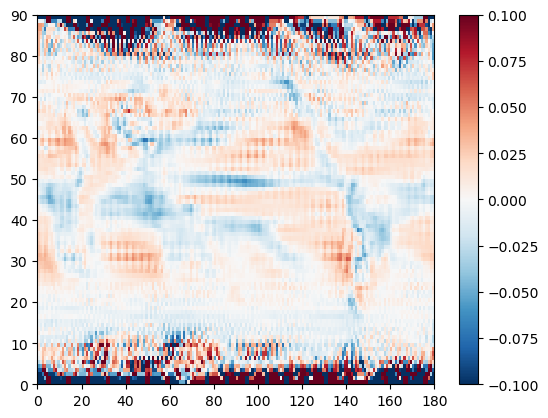

In [9]:
plt.pcolormesh(data.omega.sel(pressure_levels=50000)[0], vmax=0.1, vmin=-0.1, cmap='RdBu_r')
plt.colorbar()

pic4
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:5199: UserWarning: The following kwargs were not used by contour: 'vcenter'
  cf2 = ax.contourf(omega.lon, omega.lat, omega_500, levels=20, cmap='RdBu_r', vcenter=0, vmax=0.1)


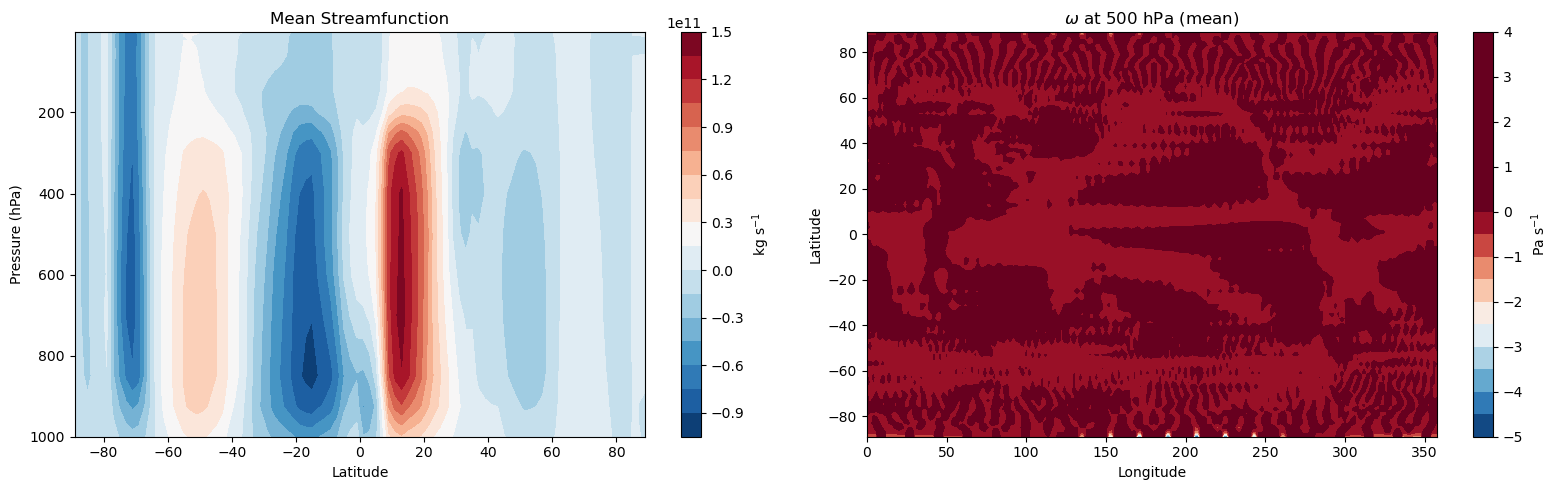

: 

In [ ]:
imp.reload(cr)
exps = [ 'pic4'] #pic4
for exp in exps:
    cr.compute_atm_streamfunction([exp], 'itcv', cart_exp=cart_exp, cart_out=cart_out)

Tests with Hadley cell

In [ ]:
imp.reload(cr)
maxHC = np.zeros(len(exps))
latHC = np.zeros(len(exps))

maxHC_c = np.zeros(len(exps))
latHC_c = np.zeros(len(exps))

minHC = np.zeros(len(exps))
lat_minHC = np.zeros(len(exps)) 
minHC_c = np.zeros(len(exps))
lat_minHC_c = np.zeros(len(exps))

widthHC = np.zeros(len(exps))
widthHC_c = np.zeros(len(exps))

widthHC_s = np.zeros(len(exps))
widthHC_s_c = np.zeros(len(exps))
for i, exp in enumerate(exps):
    widthHC[i], widthHC_c[i], widthHC_s[i], widthHC_s_c[i] = cr.return_max_500hpa(exp, 'itcv', 'psi', 'atm3d',cart_exp = cart_exp, cart_out=cart_out)
    #maxHC[i], latHC[i], maxHC_c[i], latHC_c[i], minHC[i], lat_minHC[i], minHC_c[i], lat_minHC_c[i] = cr.return_max_500hpa(exp, 'itcv', 'psi', 'atm3d',cart_exp = cart_exp, cart_out=cart_out)


p
Computing clim...


OSError: no files to open

: 

In [ ]:
widthHC_s-widthHC_s_c

array([ 0.1,  0.1, -0.1,  0.1,  0. ,  0.1,  0.1])

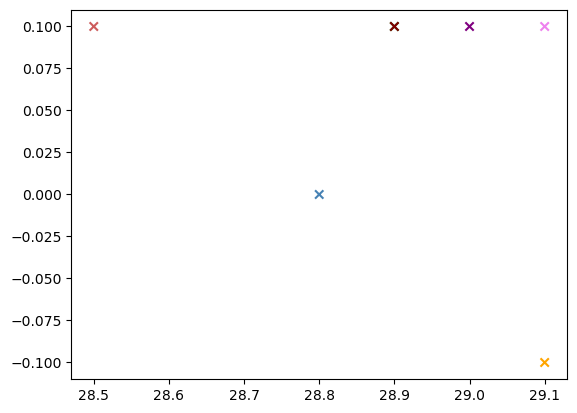

In [ ]:
#plt.scatter(widthHC_s, widthHC, color=colors)
plt.scatter(widthHC_s_c, widthHC_s-widthHC_s_c, color=colors, marker='x')
#plt.scatter(np.arange(len(exps)), widthHC - widthHC_c, color=colors)